# Step 9: ECML (AAAI 2024) through the audit

**Purpose:** put a published, citable coupled reliability method through the identical three-knob audit, closing the strawman gap. The method is ECML from *"Reliable Conflictive Multi-View Learning"* (Xu, Si, Guan, Zhao, Wu, Gao, AAAI 2024).

## Provenance ledger

- **Source:** official repository `github.com/jiajunsi/RCML`, commit `c9c5ab41e6fe62a85e5f6441a4dc7b568e1fa421` (2024-03-24)
- **License:** the repository ships no license file. Used here as research reproduction with citation, standard practice; recorded for transparency
- **Lifted verbatim (theirs):** the entire `loss_function.py` (EDL losses, KL annealing, and `get_dc_loss`, the conflict degree) and the fusion rule (evidence averaging) from `model.py`
- **Adapted (ours, adapters only):** evidence collectors swapped from their single-linear-layer MLPs to our CropCNN and PointNet trunks (same swap as our TMC port); optimizer hyperparameters adjusted for conv trunks (lr 1e-3 instead of 3e-3, minibatch 64 instead of 200); `annealing_step = 50` and `gamma = 1` kept at author defaults
- **Certification already performed:** their unmodified code, protocol, and shipped `handwritten.mat` reproduce the paper-ballpark accuracy (98.25% / 96.0% over two seeds, 80/20 split, 500 epochs) in our development environment

## The two signals this model exposes (audited separately)

- **`u` (isolated):** per-view evidential uncertainty, u = K/S, computed from the view's own data alone
- **`dc` (coupled):** the per-sample conflict degree from their `get_dc_loss`: (distance between the two views' opinions) x (both views' confidence). Trust in one view explicitly depends on the other view's opinion
- With two views the conflict degree is pairwise and symmetric: it flags "this pair conflicts" rather than naming a culprit. We track it as the LiDAR-blame signal, exactly how a deployed gate treats the suspect sensor when the camera is the trusted prior. Stated openly here, and worth one sentence in the paper

## Pre-registered predictions (written before running)

1. **`u` behaves like TMC:** ratio ~0 under both knobs (isolated by construction)
2. **`dc` is fooled by Knob 2a** (confident views disagreeing is exactly what a swap produces): ratio well above 1
3. **`dc` is blind to Knob 2b** (a 2-degree tilt changes neither view's opinion): ratio ~0
4. **Sharper:** under genuine damage the LiDAR's own u rises, which *shrinks* the confidence gate (1-u), *suppressing* dc. So S_q(dc) should be small, making the 2a ratio potentially larger than the JS baseline's 2.05. If S_q lands near zero, the ratio is unstable and the raw slopes carry the finding, as always


In [ ]:
# ============ CONFIG + LOAD Full ARTIFACTS ============
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# knob strengths: identical to the executed Step 8 (Full) run
JITTER_STD, CLUTTER_FRAC = 0.35, 0.60
MAX_ROT_DEG, MAX_TRANS_M = 2.0, 0.20
SEVS  = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
DRAWS = 3

# ECML training protocol (author defaults where portable, see ledger)
ECML_EPOCHS, ANNEALING_STEP, GAMMA, ECML_LR, ECML_BS = 80, 50, 1, 1e-3, 64

blob = torch.load("step7_kitti_objects.pt", weights_only=False)
samples, calibs = blob["samples"], blob["calibs"]
CLASSES = blob["classes"]; K = len(CLASSES)
tr_idx, te_idx = blob["tr_idx"], blob["te_idx"]

to_crop = lambda s: torch.from_numpy(s["crop"].copy()).float().permute(2, 0, 1) / 255.0
tr_crops  = torch.stack([to_crop(samples[i]) for i in tr_idx])
te_crops  = torch.stack([to_crop(samples[i]) for i in te_idx])
tr_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in tr_idx])
te_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in te_idx])
y_tr = torch.tensor([samples[i]["label"] for i in tr_idx])
y_te = torch.tensor([samples[i]["label"] for i in te_idx])
frames_test = sorted({samples[i]["frame_id"] for i in te_idx})
n_te = len(te_idx)
acc = lambda p, y: (p.argmax(1) == y).float().mean().item()
print(f"device={DEVICE}  train={len(tr_idx)}  test={n_te}")


device=cuda  train=5223  test=2247


## 1. Their code, verbatim

The next cell is the authors' `loss_function.py` pasted **unmodified** (line endings normalized only), followed by their fusion rule. Every line of method math in this notebook is theirs.


In [2]:
# ============ VERBATIM: RCML/ECML loss_function.py (commit c9c5ab4) ============
import torch
import torch.nn.functional as F


def kl_divergence(alpha, num_classes, device):
    ones = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    sum_alpha = torch.sum(alpha, dim=1, keepdim=True)
    first_term = (
        torch.lgamma(sum_alpha)
        - torch.lgamma(alpha).sum(dim=1, keepdim=True)
        + torch.lgamma(ones).sum(dim=1, keepdim=True)
        - torch.lgamma(ones.sum(dim=1, keepdim=True))
    )
    second_term = (
        (alpha - ones)
        .mul(torch.digamma(alpha) - torch.digamma(sum_alpha))
        .sum(dim=1, keepdim=True)
    )
    kl = first_term + second_term
    return kl


def loglikelihood_loss(y, alpha, device):
    y = y.to(device)
    alpha = alpha.to(device)
    S = torch.sum(alpha, dim=1, keepdim=True)
    loglikelihood_err = torch.sum((y - (alpha / S)) ** 2, dim=1, keepdim=True)
    loglikelihood_var = torch.sum(
        alpha * (S - alpha) / (S * S * (S + 1)), dim=1, keepdim=True
    )
    loglikelihood = loglikelihood_err + loglikelihood_var
    return loglikelihood


def mse_loss(y, alpha, epoch_num, num_classes, annealing_step, device=None, useKL=True):
    y = y.to(device)
    alpha = alpha.to(device)
    loglikelihood = loglikelihood_loss(y, alpha, device=device)

    if not useKL:
        return loglikelihood

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32),
    )

    kl_alpha = (alpha - 1) * (1 - y) + 1
    kl_div = annealing_coef * kl_divergence(kl_alpha, num_classes, device=device)
    return loglikelihood + kl_div


def edl_loss(func, y, alpha, epoch_num, num_classes, annealing_step, device, useKL=True):
    y = y.to(device)
    alpha = alpha.to(device)
    S = torch.sum(alpha, dim=1, keepdim=True)

    A = torch.sum(y * (func(S) - func(alpha)), dim=1, keepdim=True)

    if not useKL:
        return A

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32),
    )

    kl_alpha = (alpha - 1) * (1 - y) + 1
    kl_div = annealing_coef * kl_divergence(kl_alpha, num_classes, device=device)
    return A + kl_div


def edl_mse_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = mse_loss(target, alpha, epoch_num, num_classes, annealing_step, device=device)
    return torch.mean(loss)


def edl_log_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = edl_loss(torch.log, target, alpha, epoch_num, num_classes, annealing_step, device)
    return torch.mean(loss)


def edl_digamma_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = edl_loss(torch.digamma, target, alpha, epoch_num, num_classes, annealing_step, device)
    return torch.mean(loss)


def get_dc_loss(evidences, device):
    num_views = len(evidences)
    batch_size, num_classes = evidences[0].shape[0], evidences[0].shape[1]
    p = torch.zeros((num_views, batch_size, num_classes)).to(device)
    u = torch.zeros((num_views, batch_size)).to(device)
    for v in range(num_views):
        alpha = evidences[v] + 1
        S = torch.sum(alpha, dim=1, keepdim=True)
        p[v] = alpha / S
        u[v] = torch.squeeze(num_classes / S)
    dc_sum = 0
    for i in range(num_views):
        pd = torch.sum(torch.abs(p - p[i]) / 2, dim=2) / (num_views - 1)  # (num_views, batch_size)
        cc = (1 - u[i]) * (1 - u)  # (num_views, batch_size)
        dc = pd * cc
        dc_sum = dc_sum + torch.sum(dc, dim=0)
    dc_sum = torch.mean(dc_sum)
    return dc_sum


def get_loss(evidences, evidence_a, target, epoch_num, num_classes, annealing_step, gamma, device):
    target = F.one_hot(target, num_classes)
    alpha_a = evidence_a + 1
    loss_acc = edl_digamma_loss(alpha_a, target, epoch_num, num_classes, annealing_step, device)
    for v in range(len(evidences)):
        alpha = evidences[v] + 1
        loss_acc += edl_digamma_loss(alpha, target, epoch_num, num_classes, annealing_step, device)
    loss_acc = loss_acc / (len(evidences) + 1)
    loss = loss_acc + gamma * get_dc_loss(evidences, device)
    return loss


# ============ VERBATIM fusion rule from their model.py: evidence averaging ============
def average_evidence_fusion(evidences):
    evidence_a = evidences[0]
    for i in range(1, len(evidences)):
        evidence_a = (evidences[i] + evidence_a) / 2
    return evidence_a


## 2. Lock 1: independent re-derivation check

`get_dc_loss` is re-computed here from scratch (straight from the paper's equations, not their code) on random inputs, and must match their function numerically. This certifies the pasted block computes what the paper says, and any reader can rerun it.

Alongside it, `per_sample_conflict` extracts the **per-sample, per-view** conflict degree, which is their exact quantity before the final batch mean (the audit needs individual scores, not the training scalar). Its consistency with their function is asserted, not assumed.


In [ ]:
# ============ LOCK 1 ============
def per_sample_conflict(evidences, device="cpu"):
    batch, num_classes = evidences[0].shape
    p = torch.zeros((num_views, batch, num_classes)).to(device)
    u = torch.zeros((num_views, batch)).to(device)
    for v in range(num_views):
        alpha = evidences[v] + 1
        S = torch.sum(alpha, dim=1, keepdim=True)
        p[v] = alpha / S
        u[v] = torch.squeeze(num_classes / S)
    out = torch.zeros((num_views, batch)).to(device)
    for i in range(num_views):
        pd = torch.sum(torch.abs(p - p[i]) / 2, dim=2) / (num_views - 1)
        cc = (1 - u[i]) * (1 - u)
        out[i] = torch.sum(pd * cc, dim=0)
    return out

def conflict_manual_2view(e0, e1):
    a0, a1 = e0 + 1, e1 + 1
    p0, p1 = a0 / a0.sum(1, keepdim=True), a1 / a1.sum(1, keepdim=True)
    u0 = e0.shape[1] / a0.sum(1); u1 = e1.shape[1] / a1.sum(1)
    tv = 0.5 * (p0 - p1).abs().sum(1)          # projected distance
    cc = (1 - u0) * (1 - u1)                   # conflict certainty
    per_view = tv * cc                         # same for both views (pairwise)
    return per_view

torch.manual_seed(7)
e = {0: F.softplus(torch.randn(64, 3) * 3), 1: F.softplus(torch.randn(64, 3) * 3)}
ps   = per_sample_conflict(e)
man  = conflict_manual_2view(e[0], e[1])
ref  = get_dc_loss(e, "cpu")                                  # their function, verbatim
assert torch.allclose(ps[0], man, atol=1e-6), "per-sample != manual re-derivation"
assert torch.allclose(ps[1], man, atol=1e-6), "pairwise symmetry violated"
assert torch.allclose(ps.sum(0).mean(), ref, atol=1e-6), "per-sample mean != their get_dc_loss"
print("LOCK 1 PASSED: pasted code == paper equations == per-sample readout")


LOCK 1 PASSED: pasted code == paper equations == per-sample readout


## 3. ECML on KITTI: their heart, our trunks

Their `EvidenceCollector` for Handwritten is a **single linear layer + softplus** (their code, their scale). Our views are images and point clouds, so the collectors become the same CropCNN and PointNet trunks used for TMC in Step 8, ending in softplus evidence, exactly the trunk swap already performed for TMC. Training uses their `get_loss` verbatim: per-view + fused EDL digamma losses with annealed KL, plus `gamma * get_dc_loss` (the conflict regularizer), `gamma = 1` and `annealing_step = 50` at author defaults.


In [4]:
# ============ MODEL + TRAIN ============
class EvidCropNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.trunk = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                   nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, K))
    def forward(self, x):
        return F.softplus(self.trunk(x))

class EvidPointNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, K))
    def forward(self, x):
        return F.softplus(self.head(self.mlp(x.transpose(1, 2)).max(dim=2).values))

ecml_cam, ecml_lid = EvidCropNet().to(DEVICE), EvidPointNet().to(DEVICE)
opt = torch.optim.Adam(list(ecml_cam.parameters()) + list(ecml_lid.parameters()),
                       lr=ECML_LR, weight_decay=1e-5)

for ep in range(1, ECML_EPOCHS + 1):
    ecml_cam.train(); ecml_lid.train()
    perm = torch.randperm(len(tr_idx))
    tot = 0.0
    for i in range(0, len(perm), ECML_BS):
        b = perm[i:i+ECML_BS]
        evid = {0: ecml_cam(tr_crops[b].to(DEVICE)), 1: ecml_lid(tr_points[b].to(DEVICE))}
        ev_a = average_evidence_fusion(evid)
        loss = get_loss(evid, ev_a, y_tr[b].to(DEVICE), ep, K, ANNEALING_STEP, GAMMA, DEVICE)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(b)
    if ep % 20 == 0:
        print(f"  epoch {ep:3d}  loss {tot/len(tr_idx):.3f}")

ecml_cam.eval(); ecml_lid.eval()
@torch.no_grad()
def evid_batched(model, x, bs=256):
    return torch.cat([model(x[i:i+bs].to(DEVICE)).cpu() for i in range(0, len(x), bs)])

e_cam_clean = evid_batched(ecml_cam, te_crops)          # camera side, fixed clean
e_lid_clean = evid_batched(ecml_lid, te_points)
fused = average_evidence_fusion([e_cam_clean, e_lid_clean])
print(f"ECML per-view acc  cam {acc(e_cam_clean, y_te):.3f}  lid {acc(e_lid_clean, y_te):.3f}"
      f"  fused {acc(fused, y_te):.3f}")


  epoch  20  loss 0.268
  epoch  40  loss 0.212
  epoch  60  loss 0.194
  epoch  80  loss 0.152
ECML per-view acc  cam 0.951  lid 0.997  fused 0.997


## 4. The two audited signals

Both are read for the LiDAR view, higher = more distrust, mirroring every method in Step 8:

- **ECML u (isolated):** u = K/S from the LiDAR collector's evidence alone
- **ECML dc (coupled):** the conflict degree between the LiDAR's opinion (on the condition's, possibly corrupted or permuted, points) and the clean camera's opinion at the aligned slot, via the certified `per_sample_conflict`


In [ ]:
# ============ SIGNALS + HARNESS (identical to Step 8) ============
def corrupt_points_canon(points, severity, rng):
    pts = points.clone()
    if severity == 0:
        return pts
    pts[..., :3] += torch.from_numpy(
        rng.normal(0, JITTER_STD * severity, pts[..., :3].shape)).float()
    n_rep = int(CLUTTER_FRAC * severity * pts.shape[1])
    if n_rep > 0:
        for b in range(pts.shape[0]):
            xyz = pts[b, :, :3].numpy()
            lo, hi = xyz.min(0), xyz.max(0)
            ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
            sel = rng.choice(pts.shape[1], n_rep, replace=False)
            pts[b, sel, :3] = torch.from_numpy(
                ctr - span / 2 + rng.random((n_rep, 3)) * span).float()
            pts[b, sel, 3] = torch.from_numpy(rng.random(n_rep)).float()
    return pts

def misalign(idx, frac, rng):
    idx = idx.copy(); n = int(round(frac * len(idx)))
    if n > 1:
        s = rng.choice(len(idx), n, replace=False)
        idx[s] = idx[s][rng.permutation(n)]
    return idx

def make_condition(knob, sev, rng):
    cond = dict(points=te_points, perm=np.arange(n_te))
    if sev == 0:
        return cond
    if knob == "q":
        cond["points"] = corrupt_points_canon(te_points, sev, rng)
    elif knob == "2a":
        cond["perm"] = misalign(np.arange(n_te), sev, rng)

def ecml_u_signal(c):
    e_lid = evid_batched(ecml_lid, c["points"][c["perm"]])
    return (K / (e_lid + 1).sum(1)).numpy()

def ecml_dc_signal(c):
    e_lid = evid_batched(ecml_lid, c["points"][c["perm"]])
    return per_sample_conflict({0: e_cam_clean, 1: e_lid})[1].numpy()

def run_audit(signal_fn):
    knob_off = {"q": 0, "2a": 1, "2b": 2}
    curves = {}
    for knob in ("q", "2a", "2b"):
        pts = []
        for sev in SEVS:
            r = np.random.default_rng(SEED + int(sev * 1000) + knob_off[knob])
            pts.append(np.mean([signal_fn(make_condition(knob, sev, r)).mean()
                                for _ in range(DRAWS if sev > 0 else 1)]))
        curves[knob] = np.array(pts)
    S_q  = np.polyfit(SEVS, curves["q"],  1)[0]
    S_2a = np.polyfit(SEVS, curves["2a"], 1)[0]
    S_2b = np.polyfit(SEVS, curves["2b"], 1)[0]
    ratio = lambda sa: abs(sa) / abs(S_q) if S_q != 0 else float("inf")
    return dict(curves=curves, S_q=S_q, S_2a=S_2a, S_2b=S_2b,
                r_2a=ratio(S_2a), r_2b=ratio(S_2b))

results9 = {"ECML u (isolated signal)":   run_audit(ecml_u_signal),
            "ECML dc (coupled conflict)": run_audit(ecml_dc_signal)}

summary9 = pd.DataFrame({n: {"S_q": round(r["S_q"], 4),
                             "S_a (2a swap)": round(r["S_2a"], 4),
                             "S_a (2b drift)": round(r["S_2b"], 4),
                             "ratio 2a": round(r["r_2a"], 3),
                             "ratio 2b": round(r["r_2b"], 3)}
                         for n, r in results9.items()}).T
summary9


,S_q,S_a (2a swap),S_a (2b drift),ratio 2a,ratio 2b
ECML u (isolated signal),0.1921,-0.0000,-0.0,0.00,0.0
ECML dc (coupled conflict),0.1179,0.3762,-0.0,3.19,0.0


## 5. Figures: ECML curves + the panel grown to six rows

The Step 8 (Full) numbers below are constants carried over from that executed run, provenance: its summary table.


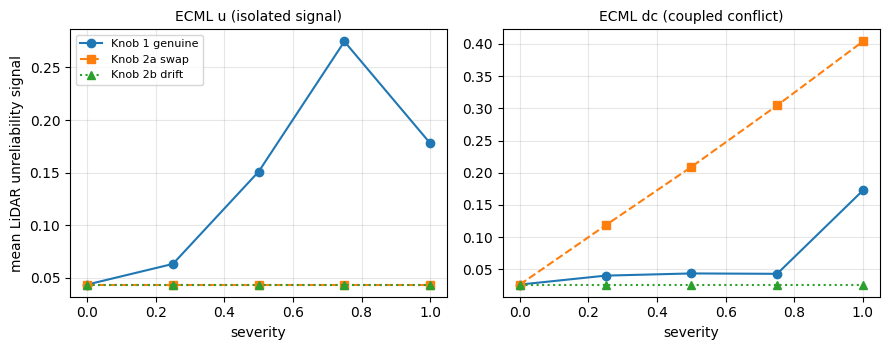

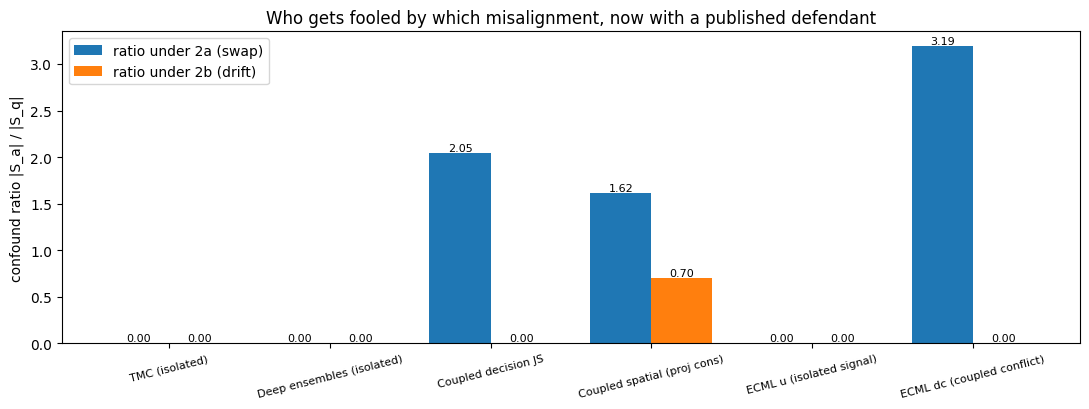

figures saved: step9_ecml_curves.png, step9_taxonomy_full.png


In [ ]:
# ============ FIGURES ============
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, (name, r) in zip(axes, results9.items()):
    c = r["curves"]
    ax.plot(SEVS, c["q"],  "o-",  label="Knob 1 genuine")
    ax.plot(SEVS, c["2a"], "s--", label="Knob 2a swap")
    ax.plot(SEVS, c["2b"], "^:",  label="Knob 2b drift")
    ax.set_title(name, fontsize=10); ax.set_xlabel("severity"); ax.grid(alpha=0.3)
axes[0].set_ylabel("mean LiDAR unreliability signal")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("step9_ecml_curves.png", dpi=150); plt.show()

prior = {"TMC (isolated)":              dict(r_2a=0.000, r_2b=0.000),
         "Deep ensembles (isolated)":   dict(r_2a=0.000, r_2b=0.000),
         "Coupled decision JS":         dict(r_2a=2.047, r_2b=0.000),
         "Coupled spatial (proj cons)": dict(r_2a=1.618, r_2b=0.702)}
panel = {**prior, **{k: dict(r_2a=v["r_2a"], r_2b=v["r_2b"]) for k, v in results9.items()}}

names = list(panel)
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.2))
b1 = ax.bar(x - w/2, [panel[n]["r_2a"] for n in names], w, label="ratio under 2a (swap)")
b2 = ax.bar(x + w/2, [panel[n]["r_2b"] for n in names], w, label="ratio under 2b (drift)")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=14, fontsize=8)
ax.set_ylabel("confound ratio |S_a| / |S_q|")
ax.set_title("Who gets fooled by which misalignment, now with a published defendant")
ax.legend(); plt.tight_layout(); plt.savefig("step9_taxonomy_full.png", dpi=150); plt.show()
print("figures saved: step9_ecml_curves.png, step9_taxonomy_full.png")


## 6. Reading the result

Check the four pre-registered predictions against the table above, in order. The decisive comparison is **inside this one model**: same network, same training run, and the isolated signal (u) versus the coupled signal (dc) should land on opposite ends of the taxonomy. If they do, the claim "the confound follows the coupling, not the uncertainty machinery" now rests on a peer-reviewed AAAI 2024 method whose own evaluation design (their `addConflict`) already treats confident cross-view disagreement as the event of interest.

**If S_q(dc) came out near zero:** the ratio column is unstable there; the finding lives in the raw slopes (tiny S_q, large S_a(2a)), which is itself the sharpest possible form of the Masquerade: a signal engineered to ignore the very damage it is supposed to help detect, while firing hard on misalignment.

**Campaign log:** summary9, both figures, ECML accuracies, Lock 1 line, and the provenance ledger.

**Next:** PDF (ICML 2024) as Step 10, the second published defendant, coupling at the confidence level instead of the opinion level.
